# Pima Indians

![](https://cdn.britannica.com/42/93542-050-E2B32DAB/women-Pima-shinny-game-field-hockey.jpg)


> The Pima /ˈpiːmə/[3] (or Akimel O'odham, also spelled Akimel Oʼotham, "River People," formerly known as Pima) are a group of Native Americans living in an area consisting of what is now central and southern Arizona, as well as northwestern Mexico in the states of Sonora and Chihuahua. The majority population of the two current bands of the Akimel O'odham in the United States are based in two reservations: the Keli Akimel Oʼodham on the Gila River Indian Community (GRIC) and the On'k Akimel O'odham on the Salt River Pima-Maricopa Indian Community (SRPMIC).

> The Keli Akimel O'odham and the Onk Akimel O'odham have various environmentally based health issues related to the decline of their traditional economy and farming. **They have the highest prevalence of type 2 diabetes in the world**, much more than is observed in other U.S. populations. While they do not have a greater risk than other tribes, the Pima people have been the subject of intensive study of diabetes, in part because they form a homogeneous group.

> The general increased diabetes prevalence among Native Americans has been hypothesized as the result of the interaction of genetic predisposition (the thrifty phenotype or thrifty genotype), as suggested by anthropologist Robert Ferrell in 1984 and a **sudden shift in diet during the last century from traditional agricultural crops to processed foods, together with a decline in physical activity**. For comparison, genetically similar O'odham in Mexico have only a slighter higher prevalence of type 2 diabetes than non-O'odham Mexicans.

https://en.wikipedia.org/wiki/Pima_people

# Family of predictive models

## Weak models

### Decision tree

[![Decision and Classification Trees, Clearly Explained!!!](http://img.youtube.com/vi/_L39rN6gz7Y/0.jpg)](https://www.youtube.com/watch?v=_L39rN6gz7Y&ab_channel=StatQuestwithJoshStarmer)

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

### KNN 

[![StatQuest: K-nearest neighbors, Clearly Explained](http://img.youtube.com/vi/HVXime0nQeI/0.jpg)](https://www.youtube.com/watch?v=HVXime0nQeI&ab_channel=StatQuestwithJoshStarmer)

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

### Logistic Regression

[![Logistic Regression](http://img.youtube.com/vi/yIYKR4sgzI8/0.jpg)](https://www.youtube.com/watch?v=yIYKR4sgzI8&ab_channel=StatQuestwithJoshStarmer)

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

### Linear Discriminant Analysis (LDA) 

[![StatQuest: Linear Discriminant Analysis (LDA) clearly explained.](http://img.youtube.com/vi/azXCzI57Yfc/0.jpg)](https://www.youtube.com/watch?v=azXCzI57Yfc&t=305s&ab_channel=StatQuestwithJoshStarmer)

https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html

## Ensambles (bagging)

### Random Forest

[![StatQuest: Random Forests](http://img.youtube.com/vi/J4Wdy0Wc_xQ/0.jpg)](https://www.youtube.com/watch?v=J4Wdy0Wc_xQ&ab_channel=StatQuestwithJoshStarmer)

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

## Ensambles (boosting)

### XGBoost

[![XGBoost ](http://img.youtube.com/vi/OtD8wVaFm6E/0.jpg)](https://www.youtube.com/watch?v=OtD8wVaFm6E&ab_channel=StatQuestwithJoshStarmer)

https://xgboost.readthedocs.io/en/stable/

### LGBM

https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html

### AdaBoost

[![AdaBoost, Clearly Explained](http://img.youtube.com/vi/LsK-xG1cLYA/0.jpg)](https://www.youtube.com/watch?v=LsK-xG1cLYA&t=36s&ab_channel=StatQuestwithJoshStarmer)

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html

# OtimizaCast

[![](https://cdns-images.dzcdn.net/images/talk/e87fcd7ff103e3a647800007e5dfbab4/500x500.jpg)](https://open.spotify.com/episode/4FU6reWKKByBxqP7NMyBUM)


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, 
                                   OneHotEncoder)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import set_config

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import precision_recall_curve as pr_curve

# yellow bricks
from yellowbrick.classifier import confusion_matrix
from yellowbrick.classifier import classification_report
from yellowbrick.classifier.rocauc import roc_auc
from yellowbrick.classifier import precision_recall_curve

import xgboost as xgb
import lightgbm as lgb

import plotly.express as px
import scikitplot as skplt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
set_config(display='diagram')

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


# 0. Setup

In [2]:
df = pd.read_csv('/kaggle/input/pima-indians-diabetes-database/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df['Glucose'].replace({0:np.nan}, inplace=True)
df['BloodPressure'].replace({0:np.nan}, inplace=True)
df['SkinThickness'].replace({0:np.nan}, inplace=True)
df['Insulin'].replace({0:np.nan}, inplace=True)
df['BMI'].replace({0:np.nan}, inplace=True)

In [4]:
# BMI_cat
df['BMI_cat'] = 'missing'
df.loc[df['BMI'] < 18.5, 'BMI_cat'] = 'underweight'
df.loc[(df['BMI'] >= 18.5) & (df['BMI'] < 25), 'BMI_cat'] = 'healthy weight'
df.loc[(df['BMI'] >= 25) & (df['BMI'] < 30), 'BMI_cat'] = 'overweight'
df.loc[df['BMI'] >= 30, 'BMI_cat'] = 'obesity'


# BloodPressure_cat
df['BloodPressure_cat'] = 'missing'
df.loc[df['BloodPressure'] < 80, 'BloodPressure_cat'] = 'normal'
df.loc[(df['BloodPressure'] >= 80) & (df['BloodPressure'] < 90), 'BloodPressure_cat'] = 'high blood pressure - stg1'
df.loc[(df['BloodPressure'] >= 90) & (df['BloodPressure'] < 120), 'BloodPressure_cat'] = 'high blood pressure - stg1'
df.loc[df['BloodPressure'] >= 120, 'BloodPressure_cat'] = 'hipertensive crisis'


# Glucose_cat
df['Glucose_cat'] = 'missing'
df.loc[df['Glucose'] < 140, 'Glucose_cat'] = 'normal'
df.loc[(df['Glucose'] >= 140) & (df['Glucose'] < 200), 'Glucose_cat'] = 'prediabetes'
df.loc[df['Glucose'] >= 200, 'Glucose_cat'] = 'diabetes'

# Glucose_cat
df['Glucose_cat'] = 'missing'
df.loc[df['Glucose'] < 140, 'Glucose_cat'] = 'normal'
df.loc[(df['Glucose'] >= 140) & (df['Glucose'] < 200), 'Glucose_cat'] = 'prediabetes'
df.loc[df['Glucose'] >= 200, 'Glucose_cat'] = 'diabetes'

# Age_cat
df.loc[df['Age'] < 31, 'Age_cat'] = 'young adults'
df.loc[(df['Age'] >= 31) & (df['Age'] < 45), 'Age_cat'] = 'middle aged adults'
df.loc[df['Age'] >= 45, 'Age_cat'] = 'old adults'

# Had_pregnancy
df['Had_pregnancy'] = df['Pregnancies'] > 0


num_vars = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'Age']
cat_vars = ['BMI_cat', 'BloodPressure_cat', 'Glucose_cat', 'Age_cat', 'Had_pregnancy']

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_cat,BloodPressure_cat,Glucose_cat,Age_cat,Had_pregnancy
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,obesity,normal,prediabetes,old adults,True
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,overweight,normal,normal,middle aged adults,True
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,healthy weight,normal,prediabetes,middle aged adults,True
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,overweight,normal,normal,young adults,True
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,obesity,normal,normal,middle aged adults,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0,obesity,normal,normal,old adults,True
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0,obesity,normal,normal,young adults,True
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0,overweight,normal,normal,young adults,True
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1,obesity,normal,normal,old adults,True


In [5]:
# predictors
X = df.drop(columns=['Outcome'])
# outcome
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"#"*20)
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (537, 13)
y_train shape: (537,)
####################
X_test shape: (231, 13)
y_test shape: (231,)


# 1. Pipeline

![](https://i0.wp.com/lifewithdata.com/wp-content/uploads/2021/04/pipeline.png?fit=681%2C431&ssl=1)

In [6]:
# numerical features
numeric_transformer = Pipeline(
    steps=[("imputer", KNNImputer(n_neighbors=5)), 
           ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[("ohe", OneHotEncoder(handle_unknown="ignore", drop='first'))])
    
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_vars),
        ("cat", categorical_transformer, cat_vars)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Pregnancies', 'Glucose', 'BloodPressure',
                                  'SkinThickness', 'Insulin',
                                  'DiabetesPedigreeFunction', 'Age']),
                                ('cat',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['BMI_cat', 'BloodPressure_cat', 'Glucose_cat',
                                  'Age_cat', 'Had_pregnancy'])])

In [7]:
preprocessor.fit_transform(X_train)

array([[ 0.93138344,  2.08616496,  0.95000854, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.63260632, -1.22085264,  0.46182233, ...,  0.        ,
         0.        ,  1.        ],
       [-0.56250219, -0.51936406, -0.67727882, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.86127931, -0.82000202, -0.18909261, ...,  0.        ,
         1.        ,  1.        ],
       [ 0.63260632,  2.28659027,  1.60092348, ...,  1.        ,
         0.        ,  1.        ],
       [ 0.03505207,  0.74999623, -1.16546502, ...,  0.        ,
         0.        ,  1.        ]])

In [8]:
preprocessor.transform(X_test)

array([[-0.26372506,  0.28233718,  0.46182233, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.03505207, -0.4191514 , -0.67727882, ...,  0.        ,
         1.        ,  1.        ],
       [ 2.12649194,  0.71659202,  1.76365222, ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 2.7240462 , -0.51936406, -0.02636387, ...,  1.        ,
         0.        ,  1.        ],
       [-0.56250219,  1.21765529,  1.43819475, ...,  1.        ,
         0.        ,  1.        ],
       [-0.86127931, -0.21872609, -0.18909261, ...,  0.        ,
         0.        ,  1.        ]])

# 2. Cross Validation

![](https://vitalflux.com/wp-content/uploads/2020/08/Screenshot-2020-08-15-at-11.13.53-AM.png)

https://scikit-learn.org/stable/modules/cross_validation.html

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=False)

split = 1
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"-"*20)
print(f"-"*20)

for train_index, test_index in skf.split(X_train, y_train):
    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    print(f"X_train shape ({split}): {X_train_fold.shape}")
    print(f"y_train shape ({split}): {y_train_fold.shape}")
    print(f"#"*20)
    print(f"X_test shape ({split}): {X_test_fold.shape}")
    print(f"y_test shape ({split}): {y_test_fold.shape}")    
    print(f"-"*20)
    split += 1

X_train shape: (537, 13)
y_train shape: (537,)
--------------------
--------------------
X_train shape (1): (429, 13)
y_train shape (1): (429,)
####################
X_test shape (1): (108, 13)
y_test shape (1): (108,)
--------------------
X_train shape (2): (429, 13)
y_train shape (2): (429,)
####################
X_test shape (2): (108, 13)
y_test shape (2): (108,)
--------------------
X_train shape (3): (430, 13)
y_train shape (3): (430,)
####################
X_test shape (3): (107, 13)
y_test shape (3): (107,)
--------------------
X_train shape (4): (430, 13)
y_train shape (4): (430,)
####################
X_test shape (4): (107, 13)
y_test shape (4): (107,)
--------------------
X_train shape (5): (430, 13)
y_train shape (5): (430,)
####################
X_test shape (5): (107, 13)
y_test shape (5): (107,)
--------------------


# 3. Exhaustive Grid Search

![](https://miro.medium.com/max/638/0*I0Uf79WuTauqKCMr.gif)

In [10]:
# params
grid_values = {'strategy': ['most_frequent', 'prior', 'stratified', 'uniform', 'constant'],
               'constant':[0, 1]}
clf = DummyClassifier(random_state=42)
grid_clf_acc = GridSearchCV(clf, 
                            param_grid = grid_values,
                            scoring = 'f1',
                            cv=5)
grid_clf_acc.fit(X_train, y_train)

# the best estimator
grid_clf_acc.best_estimator_

DummyClassifier(constant=1, random_state=42, strategy='constant')

In [11]:
pd.DataFrame(grid_clf_acc.cv_results_).sort_values(['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_constant,param_strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,0.000960,0.000100,0.001310,0.000054,1,constant,"{'constant': 1, 'strategy': 'constant'}",0.520548,0.520548,0.513889,0.513889,0.513889,0.516553,0.003262,1
3,0.000958,0.000023,0.001450,0.000035,0,uniform,"{'constant': 0, 'strategy': 'uniform'}",0.415842,0.455446,0.505051,0.464646,0.484848,0.465167,0.030019,2
8,0.000870,0.000013,0.001489,0.000286,1,uniform,"{'constant': 1, 'strategy': 'uniform'}",0.415842,0.455446,0.505051,0.464646,0.484848,0.465167,0.030019,2
2,0.000913,0.000042,0.001652,0.000033,0,stratified,"{'constant': 0, 'strategy': 'stratified'}",0.305556,0.361111,0.314286,0.314286,0.342857,0.327619,0.020958,4
7,0.000866,0.000016,0.001570,0.000019,1,stratified,"{'constant': 1, 'strategy': 'stratified'}",0.305556,0.361111,0.314286,0.314286,0.342857,0.327619,0.020958,4
0,0.000982,0.000139,0.001420,0.000102,0,most_frequent,"{'constant': 0, 'strategy': 'most_frequent'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6
1,0.000865,0.000021,0.001292,0.000017,0,prior,"{'constant': 0, 'strategy': 'prior'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6
4,0.000955,0.000031,0.001417,0.000100,0,constant,"{'constant': 0, 'strategy': 'constant'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6
5,0.000859,0.000016,0.001291,0.000013,1,most_frequent,"{'constant': 1, 'strategy': 'most_frequent'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6
6,0.000858,0.000014,0.001275,0.000009,1,prior,"{'constant': 1, 'strategy': 'prior'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6


# 4. All together now


[![All Together Now ](http://img.youtube.com/vi/73lj5qJbrms/0.jpg)](https://www.youtube.com/watch?v=73lj5qJbrms&ab_channel=TheBeatles-Topic)



## 4.1 Training with pipeline

In [12]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(**{'constant': 1, 'strategy': 'constant'}, random_state=42)),
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['BMI_cat',
                                                   'BloodPressure_cat',
                                                   'Glucose_cat', 'Age_cat',
                                                   'Had_pregnancy'])])),
                ('clf',
                 DummyClassifier(constant=1, random_state=42,
                                 strategy='constant'))])

In [13]:
pipeline[0].fit_transform(X_train)

array([[ 0.93138344,  2.08616496,  0.95000854, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.63260632, -1.22085264,  0.46182233, ...,  0.        ,
         0.        ,  1.        ],
       [-0.56250219, -0.51936406, -0.67727882, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.86127931, -0.82000202, -0.18909261, ...,  0.        ,
         1.        ,  1.        ],
       [ 0.63260632,  2.28659027,  1.60092348, ...,  1.        ,
         0.        ,  1.        ],
       [ 0.03505207,  0.74999623, -1.16546502, ...,  0.        ,
         0.        ,  1.        ]])

In [14]:
pipeline.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## 4.2 Pipeline + GridSearch

In [15]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(random_state=42)),
])

grid_values = {'clf__strategy': ['most_frequent', 'prior', 'stratified', 'uniform', 'constant'],
               'clf__constant':[0, 1]}

grid_search = GridSearchCV(pipeline, 
                           grid_values, 
                           scoring = 'recall',
                           cv=5,
                           n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Pregnancies',
                                                                          'Glucose',
                                                                          'BloodPressure',
                                                                          'SkinThickness',
                                                                          'Insulin',
                                                                          'DiabetesPedigreeFunction',
                                                                          'Age']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['BMI_cat',
                                                                          'BloodPressure_cat',
                                                                          'Glucose_cat',
                                                                          'Age_cat',
                                                                          'Had_pregnancy'])])),
                                       ('clf',
                                        DummyClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__constant': [0, 1],
                         'clf__strategy': ['most_frequent', 'prior',
                                           'stratified', 'uniform',
                                           'constant']},
             scoring='recall')

In [16]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['BMI_cat',
                                                   'BloodPressure_cat',
                                                   'Glucose_cat', 'Age_cat',
                                                   'Had_pregnancy'])])),
                ('clf',
                 DummyClassifier(constant=1, random_state=42,
                                 strategy='constant'))])

In [17]:
grid_search.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [18]:
grid_search.best_estimator_.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## 4.3 Pipeline + Decision Tree + GridSearch

In [19]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(random_state=42)),
])

grid_values = [
    {
        'clf': [DecisionTreeClassifier(random_state=42)],
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': np.arange(3, 7),
        'clf__class_weight': ['balanced', None],
    }
]

grid_search = GridSearchCV(pipeline, 
                           grid_values, 
                           scoring = 'recall',
                           cv=5,
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py", line 394, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/opt/conda/lib/python3.7/site-packages/sklearn/tree/_classes.py", line 942, in fit
    X_idx_sorted=X_idx_sorted,
  File "/opt/conda/lib/python3.7/site-packages/s

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Pregnancies',
                                                                          'Glucose',
                                                                          'BloodPressure',
                                                                          'SkinThickness',
                                                                          'Insulin',
                                                                          'DiabetesPedigreeFunction',
                                                                          'Age']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignor...
                                                                          'Glucose_cat',
                                                                          'Age_cat',
                                                                          'Had_pregnancy'])])),
                                       ('clf',
                                        DummyClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'clf': [DecisionTreeClassifier(class_weight='balanced',
                                                         criterion='entropy',
                                                         max_depth=3,
                                                         random_state=42)],
                          'clf__class_weight': ['balanced', None],
                          'clf__criterion': ['gini', 'entropy', 'log_loss'],
                          'clf__max_depth': array([3, 4, 5, 6])}],
             scoring='recall', verbose=1)

In [20]:
best = grid_search.best_estimator_
best

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['BMI_cat',
                                                   'BloodPressure_cat',
                                                   'Glucose_cat', 'Age_cat',
                                                   'Had_pregnancy'])])),
                ('clf',
                 DecisionTreeClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=3,
                                        random_state=42))])

In [21]:
pd.DataFrame(grid_search.cv_results_).sort_values(['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf,param_clf__class_weight,param_clf__criterion,param_clf__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
4,0.037224,0.006603,0.015093,0.000847,DecisionTreeClassifier(class_weight='balanced'...,balanced,entropy,3,{'clf': DecisionTreeClassifier(class_weight='b...,0.921053,0.631579,0.702703,0.864865,0.729730,0.769986,0.106890,1
0,0.031654,0.003311,0.014889,0.000412,DecisionTreeClassifier(class_weight='balanced'...,balanced,gini,3,{'clf': DecisionTreeClassifier(class_weight='b...,0.921053,0.631579,0.702703,0.729730,0.702703,0.737553,0.097358,2
7,0.032422,0.003857,0.015810,0.001553,DecisionTreeClassifier(class_weight='balanced'...,balanced,entropy,6,{'clf': DecisionTreeClassifier(class_weight='b...,0.842105,0.657895,0.567568,0.810811,0.702703,0.716216,0.100475,3
3,0.028208,0.002155,0.014802,0.000301,DecisionTreeClassifier(class_weight='balanced'...,balanced,gini,6,{'clf': DecisionTreeClassifier(class_weight='b...,0.842105,0.684211,0.648649,0.783784,0.594595,0.710669,0.090157,4
2,0.032080,0.003732,0.015095,0.001168,DecisionTreeClassifier(class_weight='balanced'...,balanced,gini,5,{'clf': DecisionTreeClassifier(class_weight='b...,0.894737,0.631579,0.702703,0.675676,0.648649,0.710669,0.095153,5
6,0.030237,0.000401,0.014691,0.000347,DecisionTreeClassifier(class_weight='balanced'...,balanced,entropy,5,{'clf': DecisionTreeClassifier(class_weight='b...,0.842105,0.631579,0.594595,0.837838,0.621622,0.705548,0.110430,6
5,0.030256,0.001536,0.015453,0.000681,DecisionTreeClassifier(class_weight='balanced'...,balanced,entropy,4,{'clf': DecisionTreeClassifier(class_weight='b...,0.789474,0.684211,0.540541,0.810811,0.567568,0.678521,0.110628,7
1,0.029188,0.001399,0.014623,0.000400,DecisionTreeClassifier(class_weight='balanced'...,balanced,gini,4,{'clf': DecisionTreeClassifier(class_weight='b...,0.605263,0.684211,0.540541,0.729730,0.540541,0.620057,0.076169,8
13,0.028891,0.000442,0.014884,0.000550,DecisionTreeClassifier(class_weight='balanced'...,None,gini,4,{'clf': DecisionTreeClassifier(class_weight='b...,0.868421,0.473684,0.432432,0.594595,0.567568,0.587340,0.152554,9
18,0.029954,0.000456,0.014667,0.000621,DecisionTreeClassifier(class_weight='balanced'...,None,entropy,5,{'clf': DecisionTreeClassifier(class_weight='b...,0.605263,0.473684,0.675676,0.783784,0.351351,0.577952,0.151580,10


### 4.3.1 Evaluating

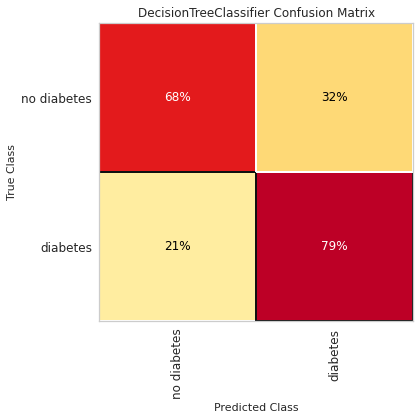

<Figure size 576x396 with 0 Axes>

In [22]:
# Instantiate the visualizer with the classification model
plt.figure(figsize=(6, 6))
confusion_matrix(
    grid_search.best_estimator_,
    X_train, y_train, X_test, y_test,
    percent=True, classes=['no diabetes', 'diabetes']
)
plt.tight_layout()

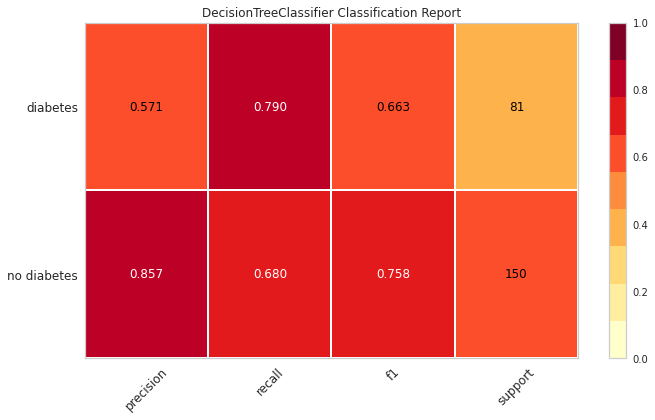

<Figure size 576x396 with 0 Axes>

In [23]:
plt.figure(figsize=(10, 6))
classification_report(
    best, X_train, y_train, 
    X_test, y_test, classes=['no diabetes', 'diabetes'], support=True
)
plt.tight_layout()

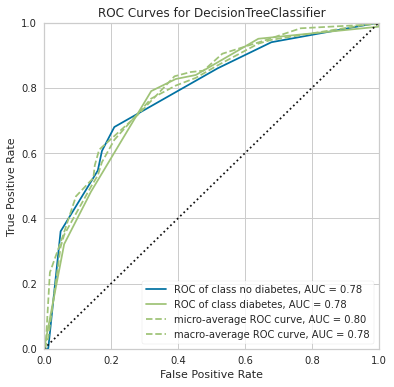

<Figure size 576x396 with 0 Axes>

In [24]:
plt.figure(figsize=(6, 6))
roc_auc(best, X_train, y_train, 
        X_test=X_test, y_test=y_test, classes=['no diabetes', 'diabetes'])
plt.tight_layout()

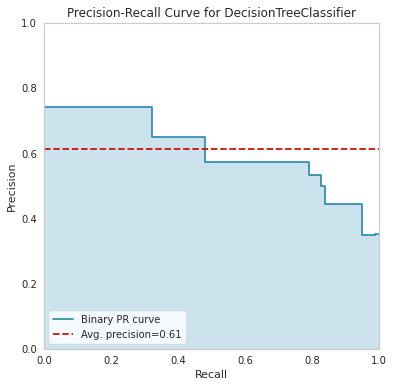

<Figure size 576x396 with 0 Axes>

In [25]:
plt.figure(figsize=(6, 6))
precision_recall_curve(best, X_train, y_train, 
                       X_test, y_test, classes=['no diabetes', 'diabetes'])
plt.tight_layout()

## 4.4 Pipeline + Several models + GridSearch

In [26]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(random_state=42)),
])

grid_values = [
    # weak models
    {
        'clf': [DecisionTreeClassifier(random_state=42)],
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': np.arange(3, 7),
        'clf__class_weight': ['balanced', None],
    },
    {
        'clf': [LogisticRegression(random_state=42, n_jobs = -1)],
        'clf__penalty': ['l1', 'l2'],
        'clf__class_weight': ['balanced', None],
    },
    {
        'clf': [KNeighborsClassifier(n_jobs = -1)],
        'clf__n_neighbors': np.arange(5, 10),
        'clf__weights': ['uniform', 'distance'],
    },
    # ensemble
    {
        'clf': [RandomForestClassifier(n_jobs = -1, random_state=42)],
        'clf__n_estimators': np.arange(2, 10, 2),
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': np.arange(3, 7),
        'clf__class_weight': ['balanced', 'balanced_subsample', None],

    }, 
    {
        'clf': [xgb.XGBClassifier()],
        'clf__max_depth': np.arange(3, 7),
    }, 
    {
        'clf': [lgb.LGBMClassifier(n_jobs=-1)],
        'clf__max_depth': np.arange(3, 7),
    },
    {
        'clf': [AdaBoostClassifier()],
        'clf__n_estimators': np.arange(2, 10, 2),
    },    
    
]

grid_search = GridSearchCV(pipeline, 
                           grid_values, 
                           scoring = 'recall',
                           cv=5,
                           n_jobs=-1,
                           verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 194 candidates, totalling 970 fits
[CV] END clf=DecisionTreeClassifier(random_state=42), clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=3; total time=   0.0s
[CV] END clf=DecisionTreeClassifier(random_state=42), clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=4; total time=   0.0s
[CV] END clf=DecisionTreeClassifier(random_state=42), clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=5; total time=   0.0s
[CV] END clf=DecisionTreeClassifier(random_state=42), clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=5; total time=   0.1s
[CV] END clf=DecisionTreeClassifier(random_state=42), clf__class_weight=balanced, clf__criterion=entropy, clf__max_depth=3; total time=   0.1s
[CV] END clf=DecisionTreeClassifier(random_state=42), clf__class_weight=balanced, clf__criterion=entropy, clf__max_depth=3; total time=   0.1s
[CV] END clf=DecisionTreeClassifier(random_state=42), clf__class_weight=balanced, clf__crit

/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  UserWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  UserWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  UserWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  UserWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in colu


[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=balanced_subsample, clf__criterion=log_loss, clf__max_depth=3, clf__n_estimators=8; total time=   0.1s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=balanced_subsample, clf__criterion=log_loss, clf__max_depth=3, clf__n_estimators=8; total time=   0.1s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=balanced_subsample, clf__criterion=log_loss, clf__max_depth=4, clf__n_estimators=6; total time=   0.1s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=balanced_subsample, clf__criterion=log_loss, clf__max_depth=4, clf__n_estimators=6; total time=   0.1s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=balanced_subsample, clf__criterion=log_loss, clf__max_depth=4, clf__n_estimators=6; total time=   0.1s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf_

/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  UserWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  UserWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  UserWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  UserWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_encoders.py:174: UserWarning: Found unknown categories in colu


[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=None, clf__criterion=entropy, clf__max_depth=5, clf__n_estimators=2; total time=   0.2s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=None, clf__criterion=entropy, clf__max_depth=5, clf__n_estimators=2; total time=   0.2s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=None, clf__criterion=entropy, clf__max_depth=5, clf__n_estimators=4; total time=   0.2s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=None, clf__criterion=entropy, clf__max_depth=5, clf__n_estimators=8; total time=   0.2s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=None, clf__criterion=entropy, clf__max_depth=5, clf__n_estimators=8; total time=   0.2s
[CV] END clf=RandomForestClassifier(n_jobs=-1, random_state=42), clf__class_weight=None, clf__criterion=entropy, clf__max_depth=6, clf__n_estima

/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
290 fits failed out of a total of 970.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py", line 394, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/opt/conda/lib/python3.7/site-packages/sklearn/tree/_classes.py", line 942, in fit
    X_idx_sorted=X_idx_sorted,
  File "/opt/conda/lib/python3.7/site-packages/

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Pregnancies',
                                                                          'Glucose',
                                                                          'BloodPressure',
                                                                          'SkinThickness',
                                                                          'Insulin',
                                                                          'DiabetesPedigreeFunction',
                                                                          'Age']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignor...
                                                missing=nan,
                                                monotone_constraints=None,
                                                n_estimators=100, n_jobs=None,
                                                num_parallel_tree=None,
                                                predictor=None,
                                                random_state=None,
                                                reg_alpha=None, reg_lambda=None, ...)],
                          'clf__max_depth': array([3, 4, 5, 6])},
                         {'clf': [LGBMClassifier()],
                          'clf__max_depth': array([3, 4, 5, 6])},
                         {'clf': [AdaBoostClassifier()],
                          'clf__n_estimators': array([2, 4, 6, 8])}],
             scoring='recall', verbose=2)

In [27]:
clfs = pd.DataFrame(grid_search.cv_results_).sort_values(['rank_test_score'])
clfs

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf,param_clf__class_weight,param_clf__criterion,param_clf__max_depth,param_clf__penalty,param_clf__n_neighbors,...,param_clf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
54,0.121760,0.000600,0.112951,0.000790,RandomForestClassifier(class_weight='balanced'...,balanced,entropy,3,NaN,NaN,...,2,{'clf': RandomForestClassifier(class_weight='b...,0.894737,0.789474,0.783784,0.837838,0.783784,0.817923,0.043445,1
4,0.039101,0.009721,0.014785,0.000612,DecisionTreeClassifier(random_state=42),balanced,entropy,3,NaN,NaN,...,NaN,{'clf': DecisionTreeClassifier(random_state=42...,0.921053,0.631579,0.702703,0.864865,0.729730,0.769986,0.106890,2
102,0.123716,0.002532,0.113021,0.001851,RandomForestClassifier(class_weight='balanced'...,balanced_subsample,entropy,3,NaN,NaN,...,2,{'clf': RandomForestClassifier(class_weight='b...,0.894737,0.789474,0.486486,0.864865,0.783784,0.763869,0.145134,3
39,0.125782,0.001256,0.116258,0.003200,RandomForestClassifier(class_weight='balanced'...,balanced,gini,3,NaN,NaN,...,4,{'clf': RandomForestClassifier(class_weight='b...,0.815789,0.684211,0.837838,0.702703,0.648649,0.737838,0.075022,4
0,0.027638,0.003545,0.014483,0.000393,DecisionTreeClassifier(random_state=42),balanced,gini,3,NaN,NaN,...,NaN,{'clf': DecisionTreeClassifier(random_state=42...,0.921053,0.631579,0.702703,0.729730,0.702703,0.737553,0.097358,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,0.125637,0.001406,0.000000,0.000000,RandomForestClassifier(class_weight='balanced'...,balanced_subsample,log_loss,3,NaN,NaN,...,8,{'clf': RandomForestClassifier(class_weight='b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190
78,0.127410,0.003729,0.000000,0.000000,RandomForestClassifier(class_weight='balanced'...,balanced,log_loss,5,NaN,NaN,...,2,{'clf': RandomForestClassifier(class_weight='b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,191
79,0.126579,0.003574,0.000000,0.000000,RandomForestClassifier(class_weight='balanced'...,balanced,log_loss,5,NaN,NaN,...,4,{'clf': RandomForestClassifier(class_weight='b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,192
8,0.033753,0.005749,0.000000,0.000000,DecisionTreeClassifier(random_state=42),balanced,log_loss,3,NaN,NaN,...,NaN,{'clf': DecisionTreeClassifier(random_state=42...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193


In [28]:
clfs['param_clf'] = clfs['param_clf'].astype(str)
clfs['param_clf'] = clfs['param_clf'].str[0:20]

In [29]:
fig = px.box(clfs, y="param_clf", x="mean_test_score")
fig.show()

In [30]:
best = grid_search.best_estimator_
best

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['BMI_cat',
                                                   'BloodPressure_cat',
                                                   'Glucose_cat', 'Age_cat',
                                                   'Had_pregnancy'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=3,
                                        n_estimators=2, n_jobs=-1,
                                        random_state=42))])

### 4.4.1 Evaluating

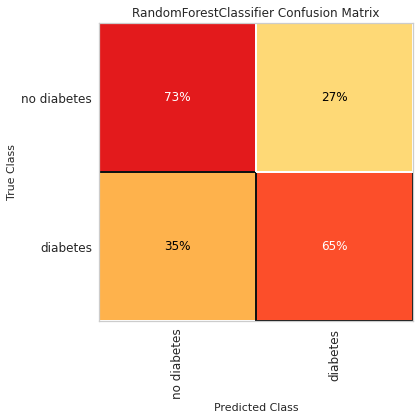

<Figure size 576x396 with 0 Axes>

In [31]:
# Instantiate the visualizer with the classification model
plt.figure(figsize=(6, 6))
confusion_matrix(
    grid_search.best_estimator_,
    X_train, y_train, X_test, y_test,
    percent=True, classes=['no diabetes', 'diabetes']
)
plt.tight_layout()

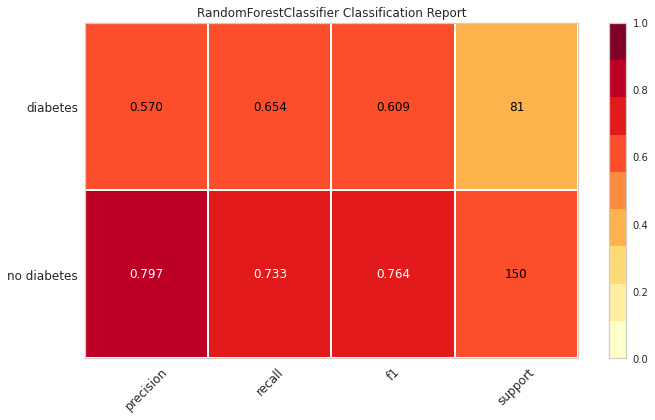

<Figure size 576x396 with 0 Axes>

In [32]:
plt.figure(figsize=(10, 6))
classification_report(
    best, X_train, y_train, 
    X_test, y_test, classes=['no diabetes', 'diabetes'], support=True
)
plt.tight_layout()

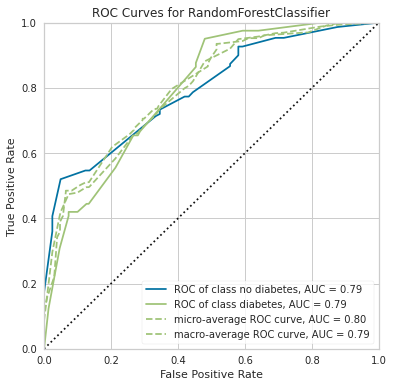

<Figure size 576x396 with 0 Axes>

In [33]:
plt.figure(figsize=(6, 6))
roc_auc(best, X_train, y_train, 
        X_test=X_test, y_test=y_test, classes=['no diabetes', 'diabetes'])
plt.tight_layout()

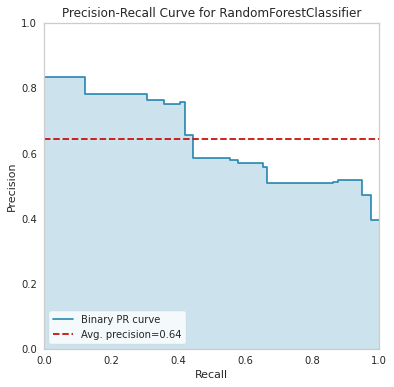

<Figure size 576x396 with 0 Axes>

In [34]:
plt.figure(figsize=(6, 6))
precision_recall_curve(best, X_train, y_train, 
                       X_test, y_test, classes=['no diabetes', 'diabetes'])
plt.tight_layout()

In [35]:
y_proba = best.predict_proba(X_test)
y_proba[0:20]

array([[0.65194986, 0.34805014],
       [0.60233375, 0.39766625],
       [0.19610396, 0.80389604],
       [0.19610396, 0.80389604],
       [0.41986563, 0.58013437],
       [0.95119989, 0.04880011],
       [0.09394795, 0.90605205],
       [0.8191165 , 0.1808835 ],
       [0.95119989, 0.04880011],
       [0.60233375, 0.39766625],
       [0.95119989, 0.04880011],
       [0.8191165 , 0.1808835 ],
       [0.8191165 , 0.1808835 ],
       [0.41986563, 0.58013437],
       [0.16225928, 0.83774072],
       [0.16225928, 0.83774072],
       [0.60233375, 0.39766625],
       [0.60233375, 0.39766625],
       [0.16225928, 0.83774072],
       [0.60233375, 0.39766625]])

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).



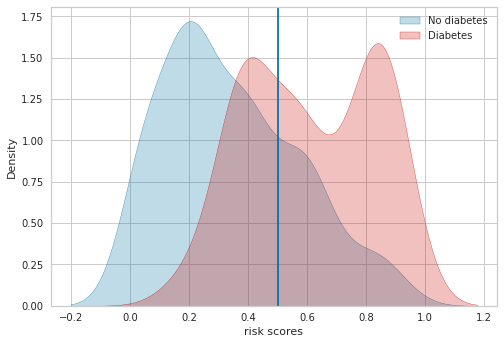

In [36]:
ground_truth = pd.DataFrame(y_test.values)
res_0 = []
res_1 = []

for i, p in enumerate(y_proba[:, 1]):
    if y_test.iloc[i] > 0:
        res_1.append(p)
    else:
        res_0.append(p)

plt.axvline(0.5, 0, 2.5)
sns.distplot(res_0, hist=False, kde_kws={"shade": True}, color='b', label='No diabetes')
sns.distplot(res_1, hist=False, kde_kws={"shade": True}, color='r', label='Diabetes')
plt.xlabel('risk scores')
plt.ylabel('Density')
plt.legend()
plt.show()

In [37]:
# calculate PR curves
precision, recall, thresholds = pr_curve(y_test, y_proba[:, 1])
# convert to f score
fscore = (2 * precision * recall) / (precision + recall)
# locate the index of the largest f score
ix = np.argmax(fscore)
best_thresh = thresholds[ix]
print('Best Threshold=%f, F-Score=%.5f' % (best_thresh, fscore[ix]))

Best Threshold=0.348050, F-Score=0.66957


/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).



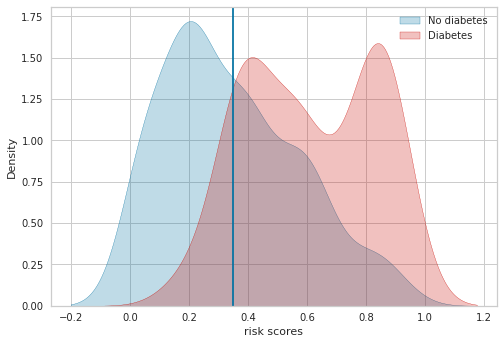

In [38]:
ground_truth = pd.DataFrame(y_test.values)
res_0 = []
res_1 = []

for i, p in enumerate(y_proba[:, 1]):
    if y_test.iloc[i] > 0:
        res_1.append(p)
    else:
        res_0.append(p)

plt.axvline(best_thresh, 0, 2.5)
sns.distplot(res_0, hist=False, kde_kws={"shade": True}, color='b', label='No diabetes')
sns.distplot(res_1, hist=False, kde_kws={"shade": True}, color='r', label='Diabetes')
plt.xlabel('risk scores')
plt.ylabel('Density')
plt.legend()
plt.show()

In [39]:
y_df = pd.DataFrame(y_proba[:, 1]).copy()
y_df[y_df[0] < best_thresh] = 0
y_df[y_df[0] >= best_thresh] = 1
y_pred_new = y_df[0].values
y_pred_new

array([1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1.,
       0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
       1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 0.,
       1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1.,
       0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0.,
       1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1.,
       0., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
       1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1.,
       1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1.,
       1., 0., 1., 0., 1.

<AxesSubplot:title={'center':'Normalized Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

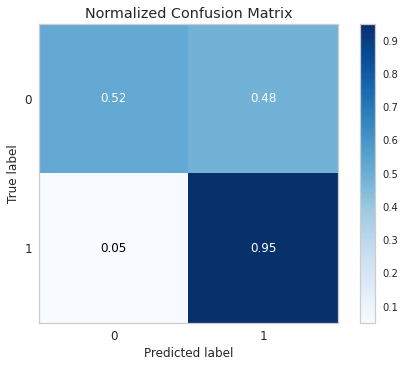

In [40]:
skplt.metrics.plot_confusion_matrix(y_test, y_pred_new, normalize=True)